
# **TRANSFER LEARNING USING PRE-TRAINED VISION MODELS FOR IMAGE RECOGNITION**

NAME: Saravanan P  
ROLL NO: 24BAD105


Task A: Dataset Preparation


In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 1. Setup Kaggle API (Ensure you have uploaded kaggle.json to Colab)
os.environ['KAGGLE_CONFIG_DIR'] = "/content"
!chmod 600 /content/kaggle.json

# Download a sample dataset (e.g., Flower classification)
!kaggle datasets download -d alxmamaev/flowers-recognition
!unzip -q flowers-recognition.zip -d dataset/

# 2. Preprocess and Load Images
# ResNet expects 224x224 images and specific normalization
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load the dataset
data_dir = 'dataset/flowers'
full_dataset = datasets.ImageFolder(data_dir, transform=transform)

# 3. Split into Training (70%), Validation (15%), and Testing (15%) sets
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

num_classes = len(full_dataset.classes)
class_names = full_dataset.classes
print(f"Classes: {class_names}")

chmod: cannot access '/content/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
100% 225M/225M [00:12<00:00, 18.2MB/s]

Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


Task B: Implementing Transfer Learning

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load Pre-trained ResNet-50
model = models.resnet50(pretrained=True)

# 2. Freeze the feature extraction layers
for param in model.parameters():
    param.requires_grad = False

# 3. Replace the final classification layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes) # Replaced with our number of classes
model = model.to(device)

# 4. Compile the model (Loss function and Optimizer)
criterion = nn.CrossEntropyLoss()
# Only optimize the parameters of the final layer
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 39.8MB/s]


Task C: Model Training and Performance Evaluation

Epoch 1/5 - Train Loss: 0.7327, Train Acc: 0.7504 - Val Loss: 0.4469, Val Acc: 0.8423
Epoch 2/5 - Train Loss: 0.4145, Train Acc: 0.8620 - Val Loss: 0.3583, Val Acc: 0.8748
Epoch 3/5 - Train Loss: 0.3492, Train Acc: 0.8815 - Val Loss: 0.3144, Val Acc: 0.8934
Epoch 4/5 - Train Loss: 0.3372, Train Acc: 0.8888 - Val Loss: 0.3373, Val Acc: 0.8825
Epoch 5/5 - Train Loss: 0.3043, Train Acc: 0.8951 - Val Loss: 0.3376, Val Acc: 0.8887

Final Test Accuracy: 0.8767


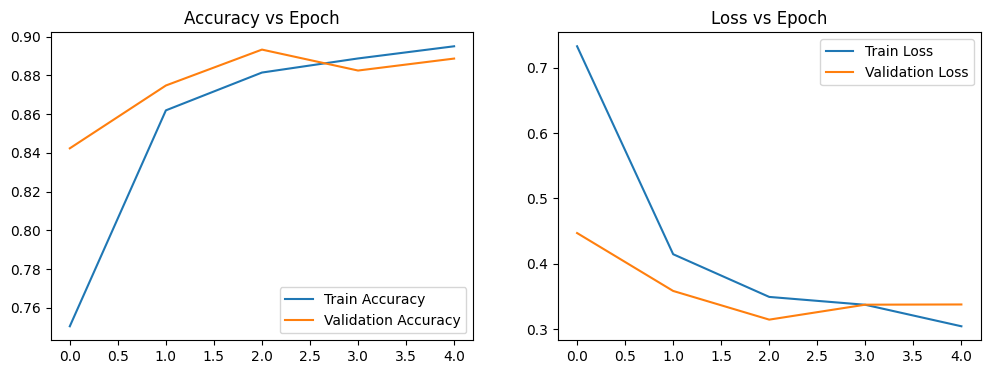

In [3]:
import matplotlib.pyplot as plt

epochs = 5
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_train += torch.sum(preds == labels).item()
        total_train += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train

    # --- Validation Phase ---
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_val += torch.sum(preds == labels).item()
            total_val += labels.size(0)

    val_loss = running_val_loss / len(val_loader)
    val_acc = correct_val / total_val

    # Record metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# --- Test Evaluation ---
model.eval()
correct_test, total_test = 0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        correct_test += torch.sum(preds == labels).item()
        total_test += labels.size(0)

test_acc = correct_test / total_test
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

# --- Visualization ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

Task D: Using Hugging Face Pre-Trained Models

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

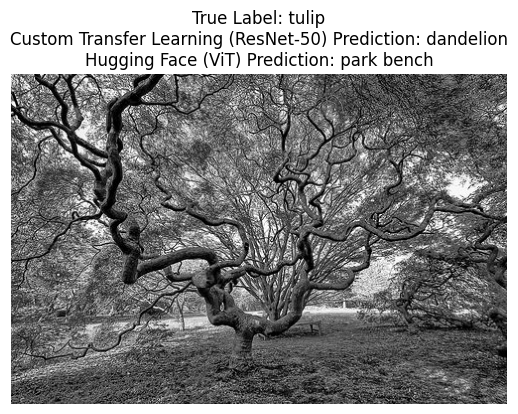

In [4]:
from transformers import ViTForImageClassification, ViTImageProcessor
from PIL import Image

# 1. Load Hugging Face Pre-Trained Model
hf_model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(hf_model_name)
hf_model = ViTForImageClassification.from_pretrained(hf_model_name)

# 2. Get a sample image from the test dataset
sample_image_path = full_dataset.samples[test_dataset.indices[0]][0]
true_label = class_names[full_dataset.samples[test_dataset.indices[0]][1]]
image = Image.open(sample_image_path).convert("RGB")

# 3. Predict using Hugging Face Model
inputs = processor(images=image, return_tensors="pt")
with torch.no_grad():
    outputs = hf_model(**inputs)
    logits = outputs.logits
    predicted_class_idx = logits.argmax(-1).item()

hf_prediction = hf_model.config.id2label[predicted_class_idx]

# 4. Predict using our Transfer Learning (ResNet-50) Model
model.eval()
# Transform the PIL image using the same transform used in Task A
tl_input = transform(image).unsqueeze(0).to(device)
with torch.no_grad():
    tl_output = model(tl_input)
    _, tl_pred_idx = torch.max(tl_output, 1)

tl_prediction = class_names[tl_pred_idx.item()]

# 5. Display the comparison
plt.imshow(image)
plt.axis('off')
plt.title(f"True Label: {true_label}\n"
          f"Custom Transfer Learning (ResNet-50) Prediction: {tl_prediction}\n"
          f"Hugging Face (ViT) Prediction: {hf_prediction}")
plt.show()